# 01 - Data Preparation

This notebook loads the five raw market and exchange-rate CSV files, aligns them by date, cleans missing observations, computes transformations, and saves reusable processed datasets.

In [4]:
from __future__ import annotations

import logging
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import FIGURES_DIR, PROCESSED_DATA_DIR, RAW_DATA_DIR, RESULTS_DIR, SERIES_FILES
from src.utils import configure_logging, ensure_directory

configure_logging()
sns.set_theme(style="whitegrid")
ensure_directory(PROCESSED_DATA_DIR)
ensure_directory(RESULTS_DIR)
ensure_directory(FIGURES_DIR)

from src.data_loader import load_all_series, merge_financial_series
from src.preprocessing import (
    clean_market_data,
    compute_first_difference,
    compute_log_returns,
    compute_returns,
    save_processed_datasets,
)
from src.visualization import plot_returns, plot_time_series

## Load Raw Series

Each CSV is expected to contain a date column and a closing-price column. The loader detects common column names and standardizes the output.

In [5]:
series_dict = load_all_series(SERIES_FILES)
market_data = merge_financial_series(series_dict)
market_data.head()

19:41:01 | INFO | src.data_loader | Loading MASI from C:\Users\SYB DELL\Desktop\market-causality-analysis\data\raw\MASI.csv
19:41:01 | INFO | src.data_loader | Loading CAC40 from C:\Users\SYB DELL\Desktop\market-causality-analysis\data\raw\CAC40.csv
19:41:01 | INFO | src.data_loader | Loading SP500 from C:\Users\SYB DELL\Desktop\market-causality-analysis\data\raw\SP500.csv
19:41:01 | INFO | src.data_loader | Loading EUR_MAD from C:\Users\SYB DELL\Desktop\market-causality-analysis\data\raw\EUR_MAD.csv
19:41:01 | INFO | src.data_loader | Loading USD_MAD from C:\Users\SYB DELL\Desktop\market-causality-analysis\data\raw\USD_MAD.csv
19:41:01 | INFO | src.data_loader | Merged market data shape: (2730, 5)


,MASI,CAC40,SP500,EUR_MAD,USD_MAD
Date,,,,,
2015-01-02,9643.190430,4252.290039,2058.199951,10.9523,9.1250
2015-01-06,9651.780273,4083.500000,2002.599976,10.9534,9.2130
2015-01-07,9750.299805,4112.729980,2025.900024,10.9345,9.2360
2015-01-08,9803.870117,4260.189941,2062.100098,10.9251,9.2645
2015-01-09,9993.190430,4179.069824,2044.800049,10.9297,9.2300


## Clean and Transform

The merged sample uses dates shared by all five series. Missing values are dropped by default to preserve transparent econometric inputs.

In [6]:
clean = clean_market_data(market_data, method="drop")
first_difference = compute_first_difference(clean)
returns = compute_returns(clean, method="simple")
log_returns = compute_log_returns(clean)

save_processed_datasets(clean, first_difference, returns, log_returns)

summary = pd.DataFrame({
    "dataset": ["clean", "first_difference", "returns", "log_returns"],
    "rows": [len(clean), len(first_difference), len(returns), len(log_returns)],
    "columns": [clean.shape[1], first_difference.shape[1], returns.shape[1], log_returns.shape[1]],
})
summary

19:41:01 | INFO | src.preprocessing | Clean market data shape after drop: (2730, 5)
19:41:01 | INFO | src.preprocessing | Saved C:\Users\SYB DELL\Desktop\market-causality-analysis\data\processed\market_data_clean.csv
19:41:01 | INFO | src.preprocessing | Saved C:\Users\SYB DELL\Desktop\market-causality-analysis\data\processed\market_data_first_difference.csv
19:41:01 | INFO | src.preprocessing | Saved C:\Users\SYB DELL\Desktop\market-causality-analysis\data\processed\market_data_returns.csv
19:41:01 | INFO | src.preprocessing | Saved C:\Users\SYB DELL\Desktop\market-causality-analysis\data\processed\market_data_log_returns.csv


,dataset,rows,columns
0,clean,2730,5
1,first_difference,2729,5
2,returns,2729,5
3,log_returns,2729,5


## Visual Inspection

Price levels reveal long-run trends and scale differences. Returns are more appropriate for VAR because they are usually closer to stationary.

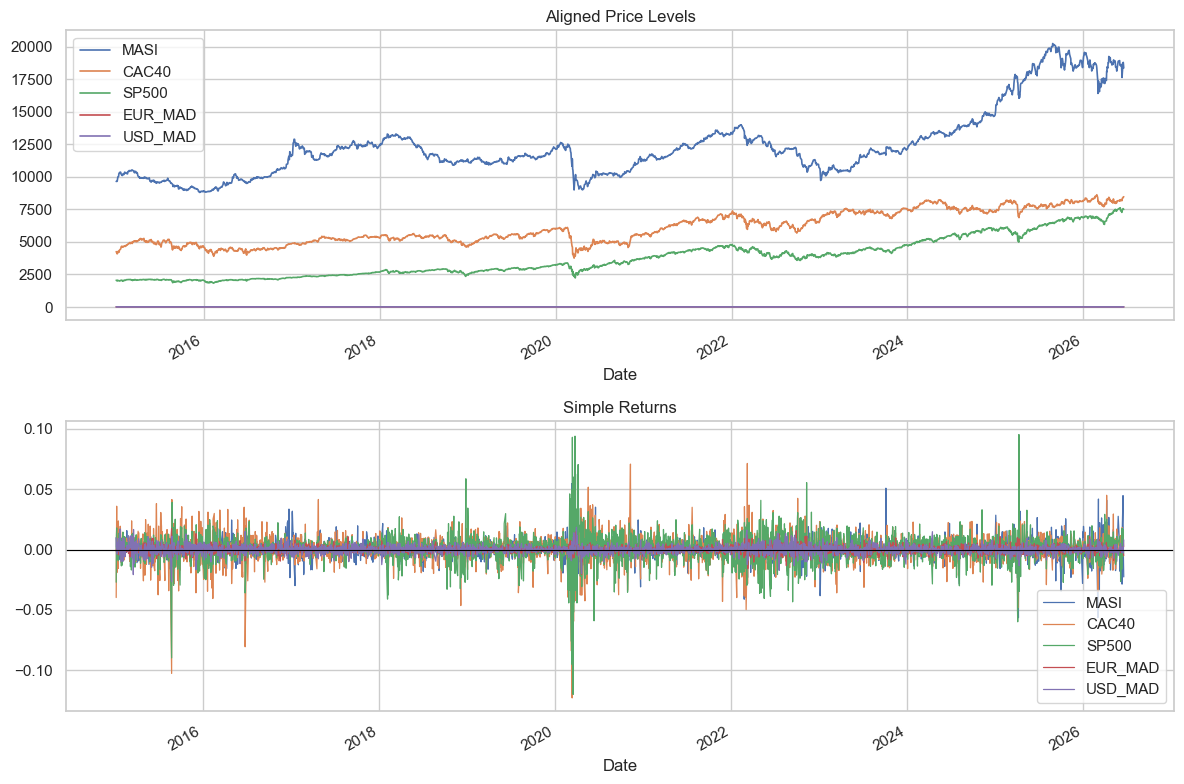

In [7]:
plot_time_series(clean, "Aligned Market and FX Price Levels", FIGURES_DIR / "raw_prices.png")
plot_returns(returns, FIGURES_DIR / "simple_returns.png")

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=False)
clean.plot(ax=axes[0], linewidth=1.2, title="Aligned Price Levels")
returns.plot(ax=axes[1], linewidth=0.9, title="Simple Returns")
axes[1].axhline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

## Interpretation

The cleaned panel is the common trading-date sample for MASI, CAC40, S&P500, EUR/MAD, and USD/MAD. First differences and returns remove much of the deterministic trend in price levels. For causality analysis, the stationary transformation should be preferred over raw prices unless cointegration motivates a vector error-correction framework.